In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Create a sample folder structure in the cloud
os.makedirs('data/train/ok', exist_ok=True)
os.makedirs('data/train/defective', exist_ok=True)

print("✅ Folders created in the cloud!")

✅ Folders created in the cloud!


In [9]:
from tensorflow.keras import layers, models

# Defining the Inspection Model
model = models.Sequential([
    # Layer 1: Detects edges/cracks
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Detects surface textures
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # The Decision Maker
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 0 = OK, 1 = Defective
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Normalize the images (convert pixels 0-255 to 0-1)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# 2. Point the "Camera" at our folders
train_generator = datagen.flow_from_directory(
    'data/train',
    target_size=(128, 128),
    batch_size=10, # Smaller batch since we are starting small
    class_mode='binary',
    subset='training'
)

print("✅ Images are indexed and ready for inspection!")

Found 72 images belonging to 2 classes.
✅ Images are indexed and ready for inspection!


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1: Detecting basic edges
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Detecting complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # The Decision Maker (The "Brain")
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output: 0 (OK) or 1 (Defective)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("🧠 Neural Network Blueprint is ready.")

🧠 Neural Network Blueprint is ready.


In [12]:
# We will run for 5 "epochs" (rounds of learning)
history = model.fit(
    train_generator,
    epochs=5
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.6667 - loss: 1.0568
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.7222 - loss: 0.5529
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.7222 - loss: 0.5223
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.7222 - loss: 0.4860
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.7500 - loss: 0.4364


Please upload an image from your 'test' folder:


Saving cast_ok_0_35.jpeg to cast_ok_0_35.jpeg
Saving cast_ok_0_37.jpeg to cast_ok_0_37.jpeg
Saving cast_ok_0_93.jpeg to cast_ok_0_93.jpeg
Saving cast_ok_0_119.jpeg to cast_ok_0_119.jpeg
Saving cast_ok_0_129.jpeg to cast_ok_0_129.jpeg
Saving cast_ok_0_196.jpeg to cast_ok_0_196.jpeg
Saving cast_ok_0_199.jpeg to cast_ok_0_199.jpeg
Saving cast_ok_0_211.jpeg to cast_ok_0_211.jpeg
Saving cast_ok_0_222.jpeg to cast_ok_0_222.jpeg
Saving cast_ok_0_265.jpeg to cast_ok_0_265.jpeg
Saving cast_ok_0_277.jpeg to cast_ok_0_277.jpeg
Saving cast_ok_0_304.jpeg to cast_ok_0_304.jpeg
Saving cast_ok_0_305.jpeg to cast_ok_0_305.jpeg
Saving cast_ok_0_312.jpeg to cast_ok_0_312.jpeg
Saving cast_ok_0_327.jpeg to cast_ok_0_327.jpeg
Saving cast_ok_0_352.jpeg to cast_ok_0_352.jpeg
Saving cast_ok_0_373.jpeg to cast_ok_0_373.jpeg
Saving cast_ok_0_423.jpeg to cast_ok_0_423.jpeg
Saving cast_ok_0_431.jpeg to cast_ok_0_431.jpeg
Saving cast_ok_0_468.jpeg to cast_ok_0_468.jpeg
Saving cast_ok_0_477.jpeg to cast_ok_0_477.jpe

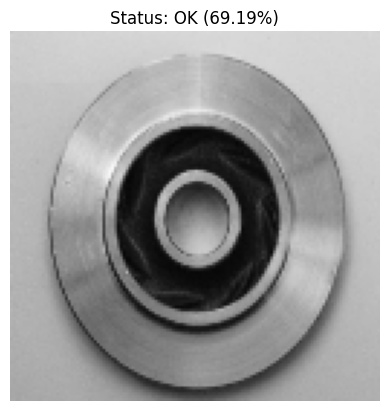

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


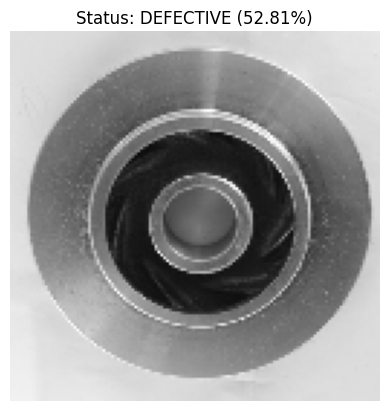

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


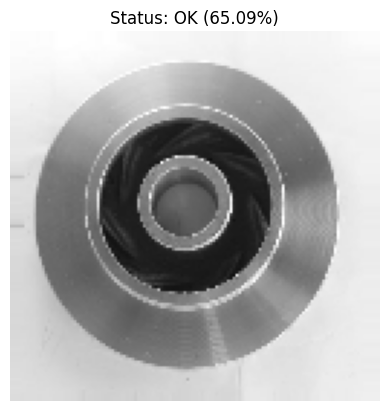

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


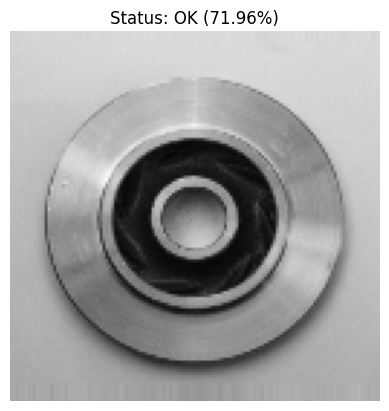

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


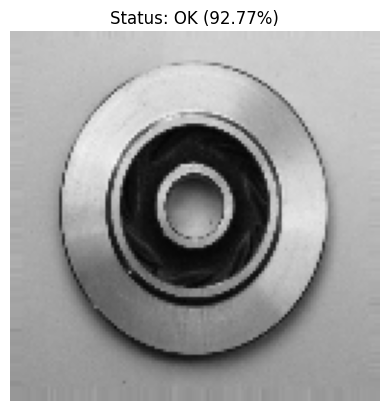

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


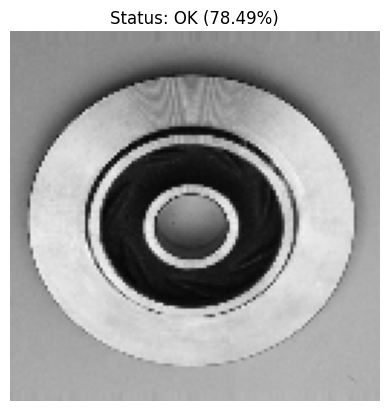

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


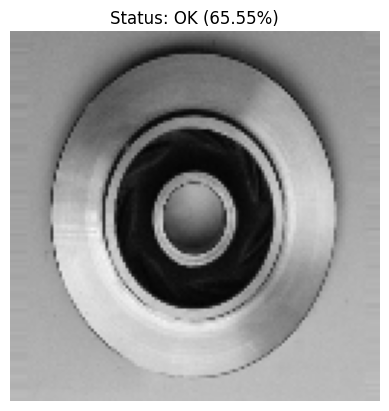

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


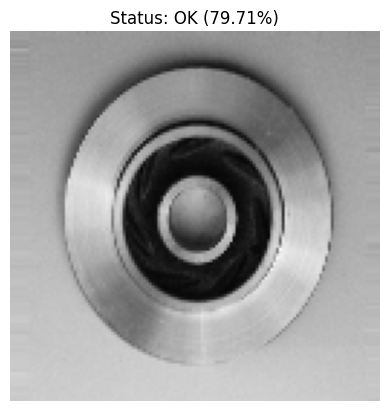

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


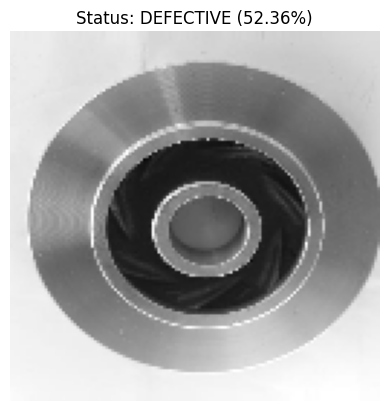

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


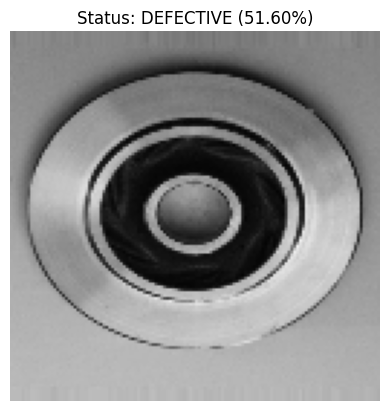

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


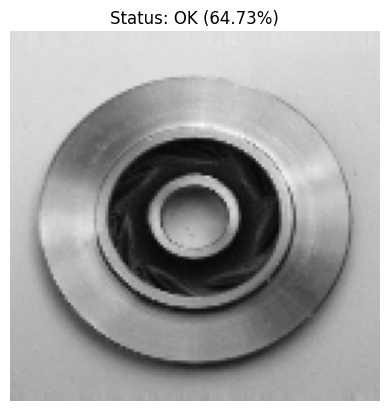

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


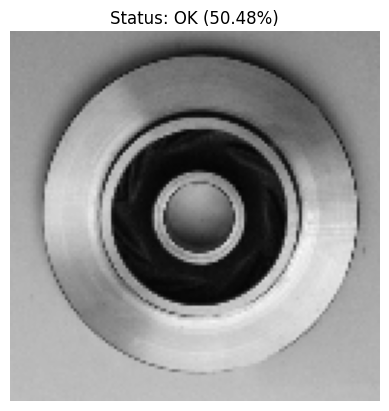

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


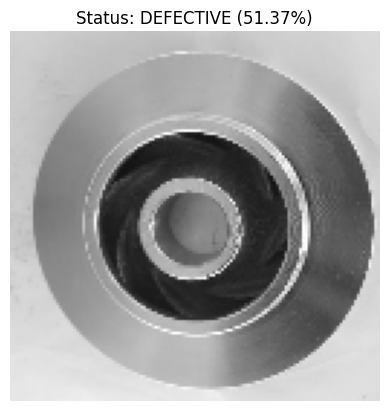

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


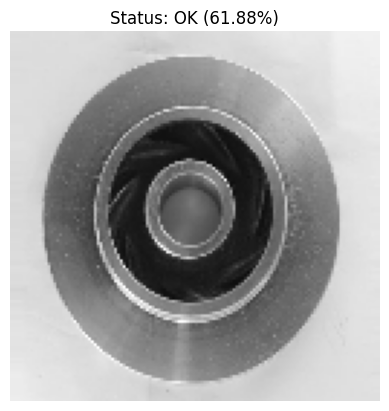

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


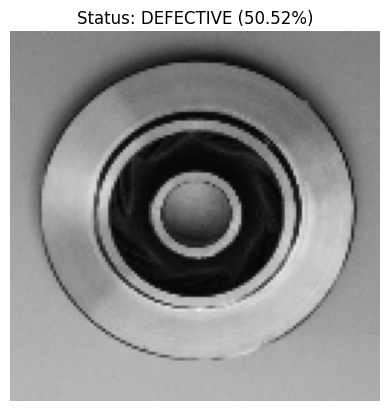

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


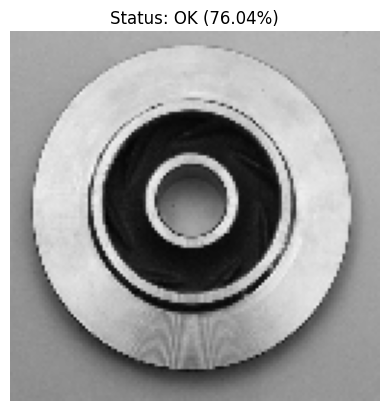

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


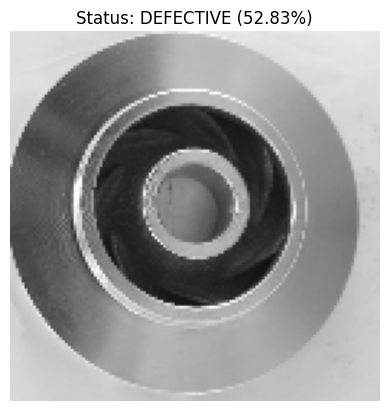

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


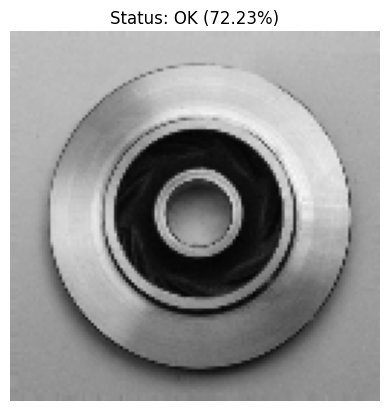

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


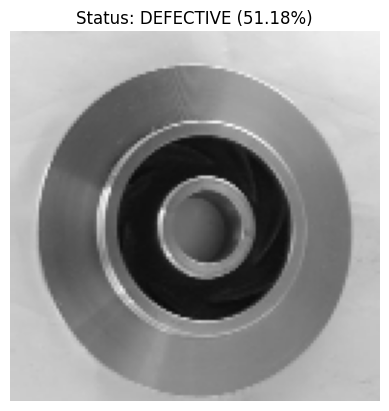

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


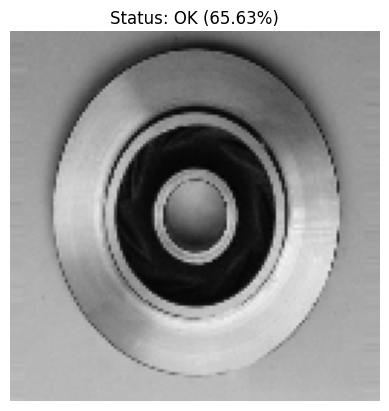

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


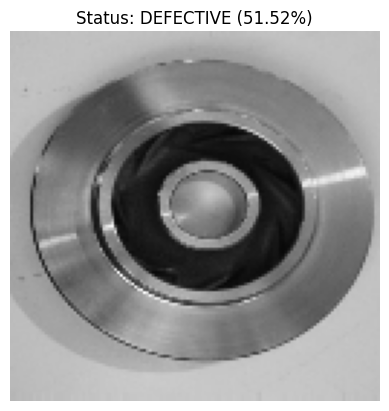

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


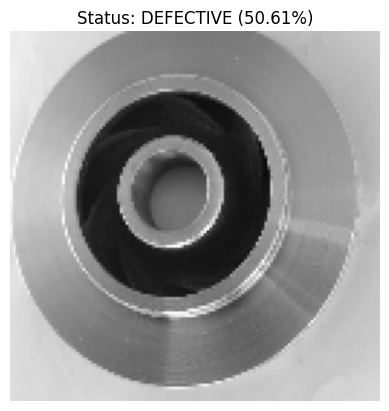

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


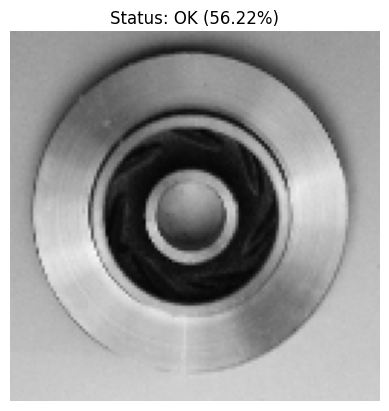

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


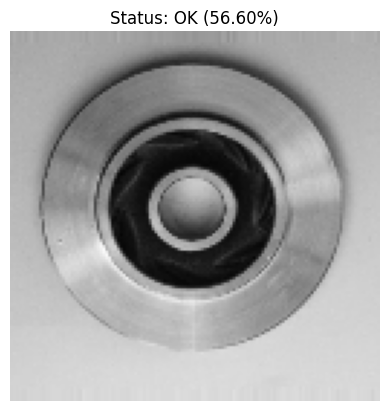

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


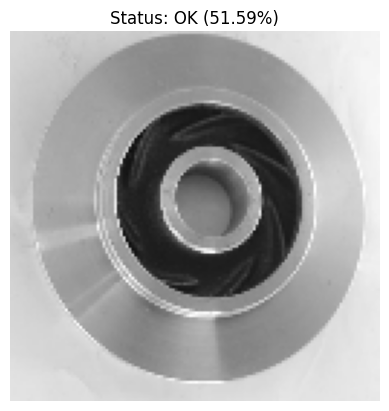

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


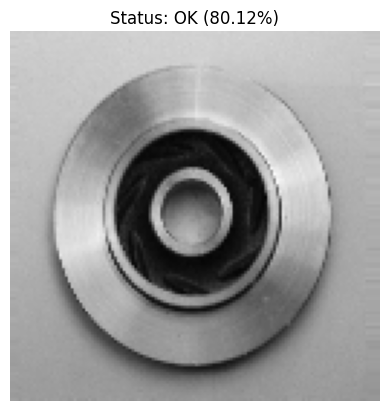

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


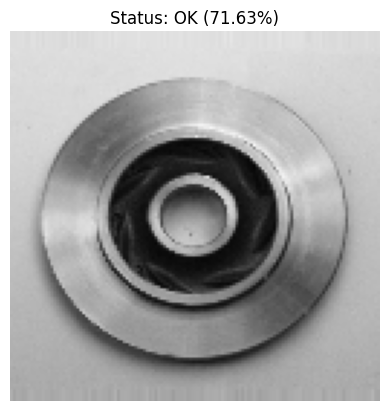

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


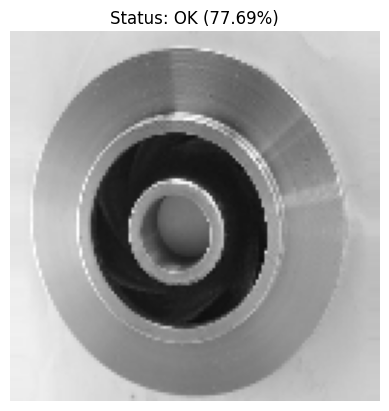

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


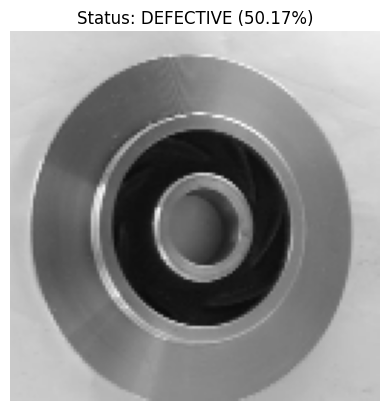

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


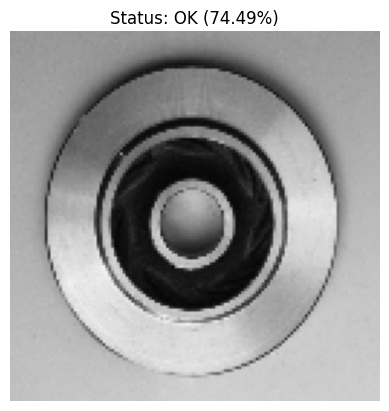

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


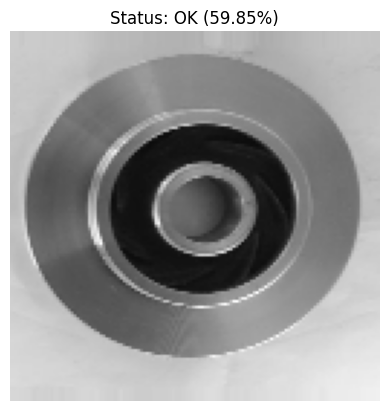

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


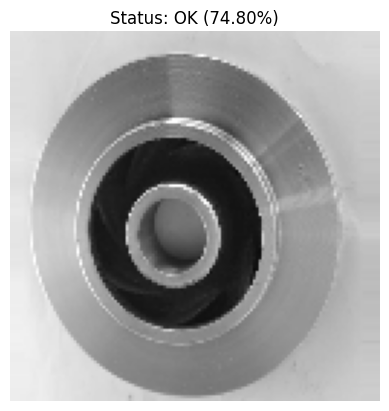

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


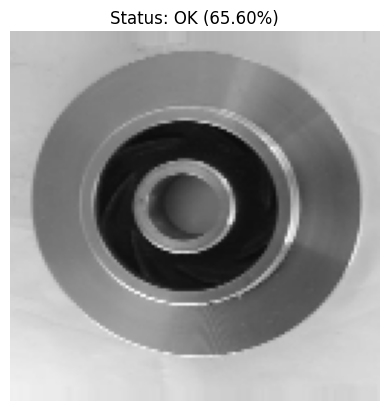

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


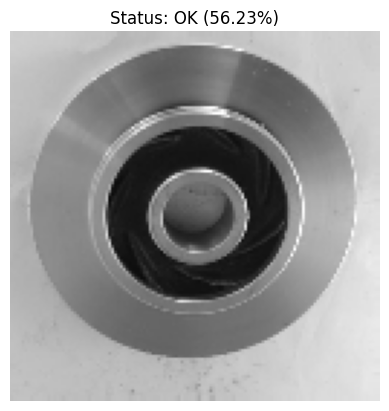

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


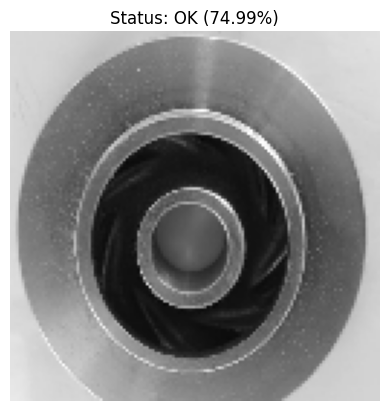

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


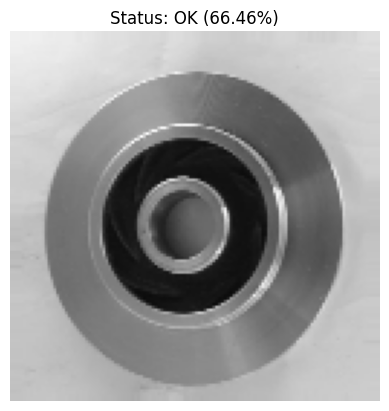

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


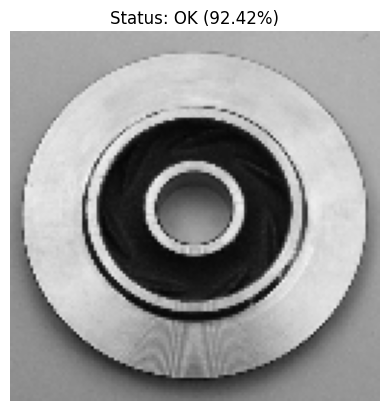

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


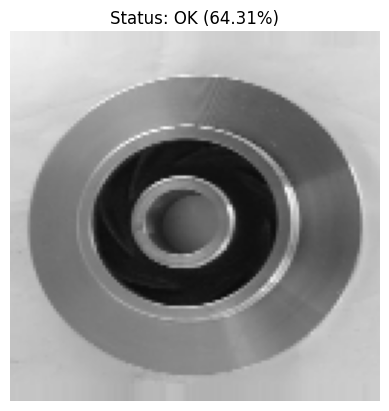

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


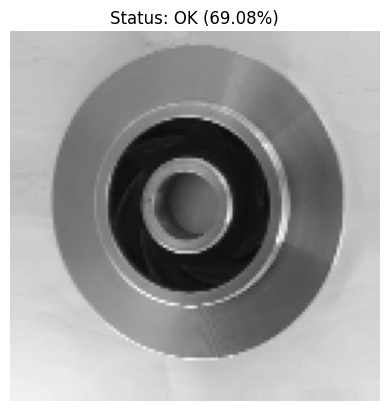

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


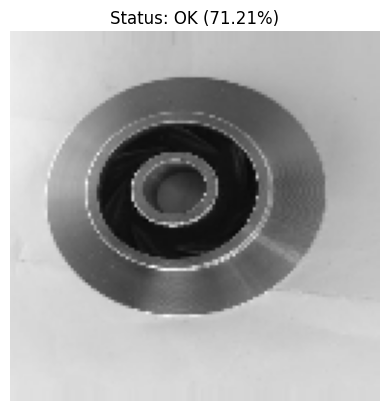

In [13]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Upload a "Mystery" image to test
print("Please upload an image from your 'test' folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Preprocessing (Making the image match the training size)
    path = '/content/' + fn
    img = image.load_img(path, target_size=(128, 128))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0 # Normalizing pixels

    # 3. Running the AI "Brain"
    classes = model.predict(x)

    # 4. Displaying the Result
    plt.imshow(img)
    plt.axis('off')

    if classes[0] > 0.5:
        plt.title(f"Status: DEFECTIVE ({classes[0][0]*100:.2f}%)")
    else:
        plt.title(f"Status: OK ({(1-classes[0][0])*100:.2f}%)")
    plt.show()

In [14]:
model.save('casting_inspector_v1.h5')
print("✅ Model saved! You can now download it from the folder icon on the left.")

✅ Model saved! You can now download it from the folder icon on the left.
